In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
df=pd.read_csv('height-weight.csv')

In [5]:
df.head() # HEIGHT IN CMS

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'height')

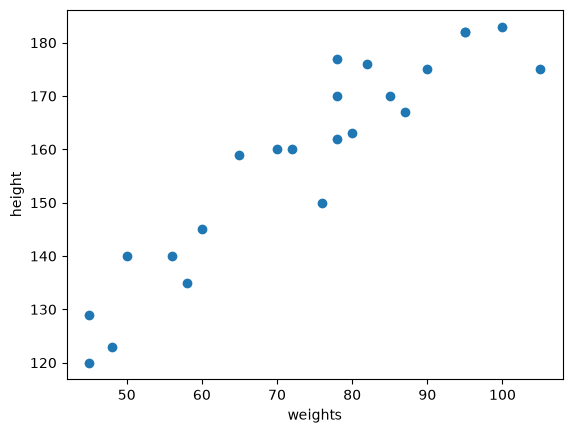

In [ ]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('weights')
plt.ylabel('height') # the diagram shows the heights increases as weight increases which shows linearly related

In [35]:
df.corr() # to find if the relation is positive or negatively related we do corr.
#.93 height shows wtr to weight 1.000 it shows that it is highly positive corelated means when x increase y also increase an same goes for decrease

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


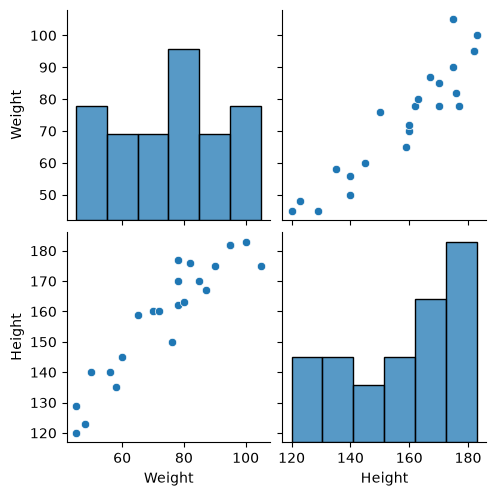

In [ ]:
import seaborn as sns
sns.pairplot(df) # as diagram shows height and weight are linearly correlated it assure us that linear regression model will work well here.

In [36]:
#step1 divide features dependent and independent
# before starting we always divide our dataset in dependent and independent features.
# when ever we divide data frame we give it in 2dimendion or 2d array. using double[[]] otherwise whole dataset will be in series as one value.
x=df[['Weight']] #independent
y=df[['Height']] #dependent
np.array(x).shape
# you can see that shape has 23 rows and 1 column shows 2d



(23, 1)

In [37]:
x.head()# now x and y both have dataframe divided values that is must before starting.

,Weight
0,45
1,58
2,48
3,60
4,70


In [38]:
#step2 split data for testing and training. testing data will be hidden from the model.  and test data ratio is usually 25 to 30% of 100%
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

#random_state=42: Fixes the random split so you get the same train/test data every time you run the code. (42 is just a commonly used number; any integer works.)

#Why X_train, X_test and y_train, y_test?

#X = input features
#y = target (labels)

#They are split together so each row in X stays matched with its correct value in y. This keeps the data aligned.

#X_train → Training input data (features)
#y_train → Correct answers (target) for X_train

#The model learns by using X_train to predict y_train.

#Similarly:

#X_test → Test input data
#y_test → Correct answers for X_test

#The model is tested by comparing its predictions on X_test with y_test.

In [39]:
#step3 We apply the z-score to data points to standardize them, so they have the same scale (mean = 0, standard deviation = 1).
#  This makes it easier to compare values and detect outliers.

# We do this because the model should learn only from the training data.

# fit(X_train) → Calculates the mean and standard deviation of the training data.
# transform(X_train) → Uses those learned values to scale the training data.

# transform(X_test) → Uses the same mean and standard deviation from X_train to scale the test data.

# If we use fit_transform(X_test), it calculates its own mean and standard deviation,
# which causes data leakage because the model gets information from the test data.
# This makes the evaluation unfair.

# In short:
# fit_transform(X_train) → Learn mean/std + scale training data.
# transform(X_test) → Only scale test data using values learned from X_train.

# Scaling means changing feature values to a common scale so large values
# do not dominate smaller values.

# StandardScaler formula:
# z score is actually scaled value = (x - mean) / standard deviation  (x is the datapoint where each value is placed at x place and transformed.

# After scaling, data has:
# Mean ≈ 0
# Standard deviation ≈ 1

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

# we dont do anything to y train and y test as they are the target/result that will be predicted by the model.
# x train has calculated its mean and sd which is used to transform the x test values that will be used as input by the model in testing.
# here in both x train and x test the inputs are just transformed to standard z scores so that bigger outlier dont dominate small values.



In [40]:
x_test #transformed input values by using sd and mean of training data. to avoid dataleak of test to model we used train sd and mean.

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [41]:
#step 4 train the model linear regresssion
from sklearn.linear_model import LinearRegression
regression=LinearRegression(n_jobs=-1) ## Create a linear regression model and use all available CPU cores to train the model (faster for large data)

In [42]:
regression.fit(x_train,y_train)

# fit() trains the model.
# It does this:
# Takes X_train → input features (e.g., age, salary, area)
# Takes y_train → correct answers (target values)
# Finds the best coefficients (weights) and intercept to create the best prediction line.
# In simple words:
# fit() = Model learns the relationship between inputs (X_train) and outputs (y_train).

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
print("coefficent/slop: ",regression.coef_)
print("Intercept: ",regression.intercept_)

coefficent/slop:  [[17.2982057]]
Intercept:  [156.47058824]


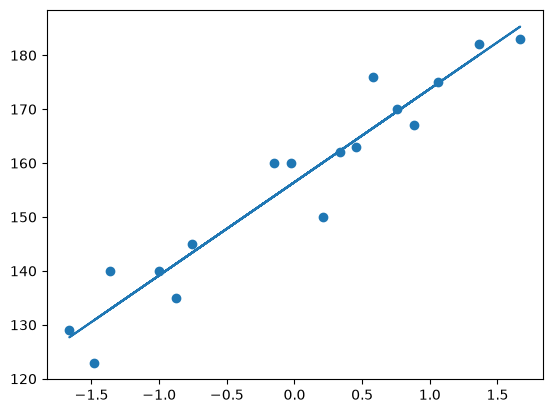

In [46]:
#step5 create best fit line
plt.scatter(x_train,y_train)
plt.plot(x_train,regression.predict(x_train)) # best fit line

In [47]:
#step6 prediction of output of test data by the model trained.
y_pred=regression.predict(x_test)

In [ ]:
#step6 performance matrices evalution of model performance.
from sklearn.metrics import  mean_squared_error,mean_absolute_error

mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)
# MSE (Mean Squared Error) = 114.84
# → Average of squared differences between actual values (y_test) and predicted values (y_pred).
# → Lower MSE means better model performance.

# MAE (Mean Absolute Error) = 9.66
# → Average absolute difference between actual and predicted values.
# → Predictions are off by about 9.66 units on average.

# RMSE (Root Mean Squared Error) = 10.71
# → Square root of MSE.
# → Shows the typical prediction error in the same unit as the target.
# → Predictions are off by about 10.71 units on average.

114.84069295228699
9.66512588679501
10.716374991212605


In [49]:
# step7 checking if the model suits the dataset by r^2 and adjusted r^2
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

# R² (R-squared):
# Shows how much variation in the target is explained by the model.
# More features can increase R² even if they are useless.

# Adjusted R²:
# Improved version of R² that penalizes unnecessary features.
# It increases only when a new feature improves the model.

# Example:
# R² = 0.85
# After adding useless feature:
# R² = 0.87 (increases)
# Adjusted R² = 0.84 (decreases)

# In short:
# R² → Model performance.
# Adjusted R² → Model performance considering number of features.
# Adjusted R² is better for multiple regression.

0.7360826717981276


**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [51]:
#adjusted r^2
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)


0.6701033397476595

In [53]:
#OLS is the method used by Linear Regression to find the best values of coefficients (weights) and intercept.

#You don't manually choose the regression line. The model uses OLS internally to calculate the line that gives the minimum prediction error.

#In short:
#LinearRegression = model
#OLS = method used by the model to learn the best line.

## OLS Linear Regression
import statsmodels.api as sm

#OLS() → Creates a Linear Regression model using the Ordinary Least Squares method.
#.fit() → Trains the model and finds the best coefficients.

#In short: It trains a regression model and calculates the best-fitting line.

#(Note: In statsmodels, the order is usually OLS(y, X), target first, features second.)
model=sm.OLS(y_train,x_train).fit()



In [54]:
pred=model.predict(x_test)
print(pred)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [55]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Tue, 14 Jul 2026   Prob (F-statistic):                       0.664
Time:                        04:28:28   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [ ]:
# to predict for a new data. with manual regression
regression.predict(scaler.transform([[72]]))

d:\Coding\VS CODE\vs code programs\python\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[155.97744705]])